<a href="https://colab.research.google.com/github/RobelDawit/Personalization_Two_Tower/blob/main/Two_tower_personalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Reducing memeory and increasing speed by storing datasets as parquet, loading into cache and explicit typing for dataset

In [ ]:
import os
import pandas as pd

data_dir = "drive/MyDrive/two+tower_data"
parquet_dir = os.path.join(data_dir, "parquet")
os.makedirs(parquet_dir, exist_ok=True)

data_cache = {}

print("Starting optimized loading + Parquet conversion...\n")

for file in os.listdir(data_dir):
    if not file.endswith('.csv'):
        continue

    file_path = os.path.join(data_dir, file)
    parquet_path = os.path.join(parquet_dir, file.replace('.csv', '.parquet'))

    print(f"Processing {file}...")

    if file == "orders.csv":
        dtype_dict = {
            'order_id': 'int32',
            'user_id': 'int32',
            'order_number': 'int16',
            'order_dow': 'int8',
            'order_hour_of_day': 'int8'
        }
        df = pd.read_csv(file_path, dtype=dtype_dict)
        df['eval_set'] = df['eval_set'].astype('category')

    elif file == "order_products__prior.csv":
        dtype_dict = {
            'order_id': 'int32',
            'product_id': 'int32',
            'add_to_cart_order': 'int16',
            'reordered': 'int8'
        }

        df = pd.read_csv(file_path, dtype=dtype_dict)

    elif file == "order_products__train.csv":
        dtype_dict = {
            'order_id': 'int32',
            'product_id': 'int32',
            'add_to_cart_order': 'int16',
            'reordered': 'int8'
        }
        df = pd.read_csv(file_path, dtype=dtype_dict)

    elif file == "products.csv":
        dtype_dict = {
            'product_id': 'int32',
            'aisle_id': 'int16',
            'department_id': 'int8'
        }
        df = pd.read_csv(file_path, dtype=dtype_dict)
        df['product_name'] = df['product_name'].astype('string')

    elif file in ["aisles.csv", "departments.csv"]:
        df = pd.read_csv(file_path)

        name_col = 'aisle' if 'aisle' in df.columns else 'department'
        if name_col in df.columns:
            df[name_col] = df[name_col].astype('category')

    else:
        df = pd.read_csv(file_path)


    df = df.drop_duplicates().reset_index(drop=True)


    if 'days_since_prior_order' in df.columns:
        df['days_since_prior_order'] = df['days_since_prior_order'].fillna(0).astype('float16')


    df.to_parquet(parquet_path, index=False, compression='snappy', engine='pyarrow')


    data_cache[file.replace('.csv', '')] = df

    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"   → Saved as {file.replace('.csv', '.parquet')} | Memory: {mem_mb:.1f} MB")

print("\n✅ All files processed and converted to Parquet!")
print("Cached keys:", list(data_cache.keys()))
print(f"Parquet files are saved in: {parquet_dir}")

Starting optimized loading + Parquet conversion...

Processing aisles.csv...
   → Saved as aisles.parquet | Memory: 0.0 MB
Processing departments.csv...
   → Saved as departments.parquet | Memory: 0.0 MB
Processing order_products__train.csv...
   → Saved as order_products__train.parquet | Memory: 14.5 MB
Processing order_products__prior.csv...
   → Saved as order_products__prior.parquet | Memory: 340.3 MB
Processing orders.csv...
   → Saved as orders.parquet | Memory: 48.9 MB
Processing products.csv...
   → Saved as products.parquet | Memory: 4.1 MB

✅ All files processed and converted to Parquet!
Cached keys: ['aisles', 'departments', 'order_products__train', 'order_products__prior', 'orders', 'products']
Parquet files are saved in: drive/MyDrive/two+tower_data/parquet


In [ ]:
orders = pd.read_parquet(os.path.join(parquet_dir, 'orders.parquet'))
prior = pd.read_parquet(os.path.join(parquet_dir, 'order_products__prior.parquet'))
train = pd.read_parquet(os.path.join(parquet_dir, 'order_products__train.parquet'))
products = pd.read_parquet(os.path.join(parquet_dir, 'products.parquet'))

#EDA

## orders  dataset

In [ ]:
display(orders.head()), orders.shape, orders.info()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,0.0
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   user_id                 int32   
 2   eval_set                category
 3   order_number            int16   
 4   order_dow               int8    
 5   order_hour_of_day       int8    
 6   days_since_prior_order  float16 
dtypes: category(1), float16(1), int16(1), int32(2), int8(2)
memory usage: 48.9 MB


(None, (3421083, 7), None)

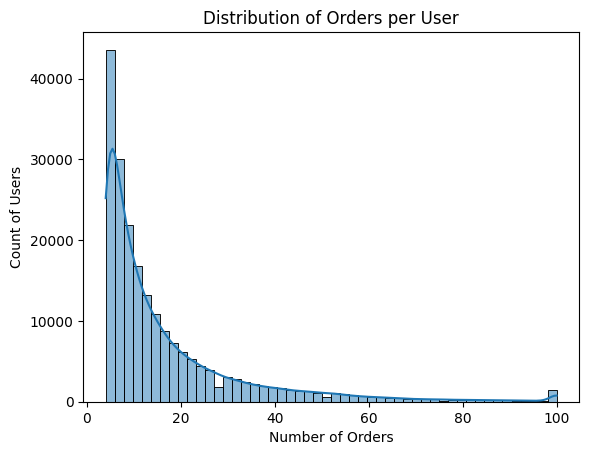

Median orders per user: 10.0
Max orders per user: 100


In [ ]:
#vizualize the distribution of orders per user

import seaborn as sns
import matplotlib.pyplot as plt


user_order_counts = orders['user_id'].value_counts()

plt.figure()
sns.histplot(user_order_counts, bins=50, kde=True)
plt.title('Distribution of Orders per User')
plt.xlabel('Number of Orders')
plt.ylabel('Count of Users')
plt.show()

print(f"Median orders per user: {user_order_counts.median():.1f}")
print(f"Max orders per user: {user_order_counts.max()}")

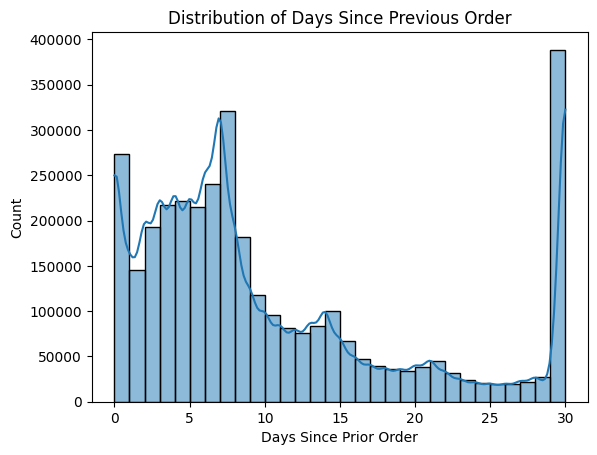

/tmp/ipykernel_2480/4020278549.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=orders, x='order_dow', palette='viridis')


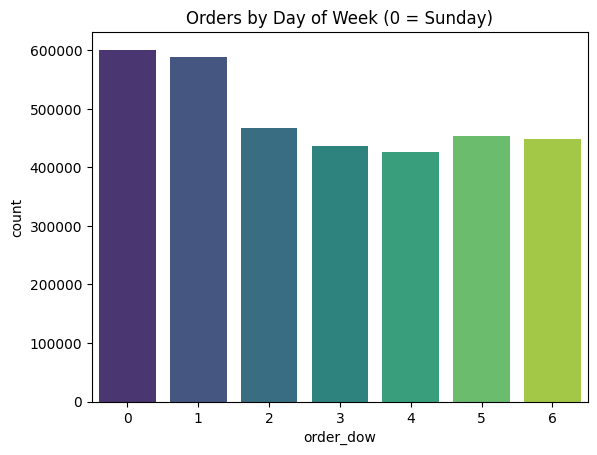

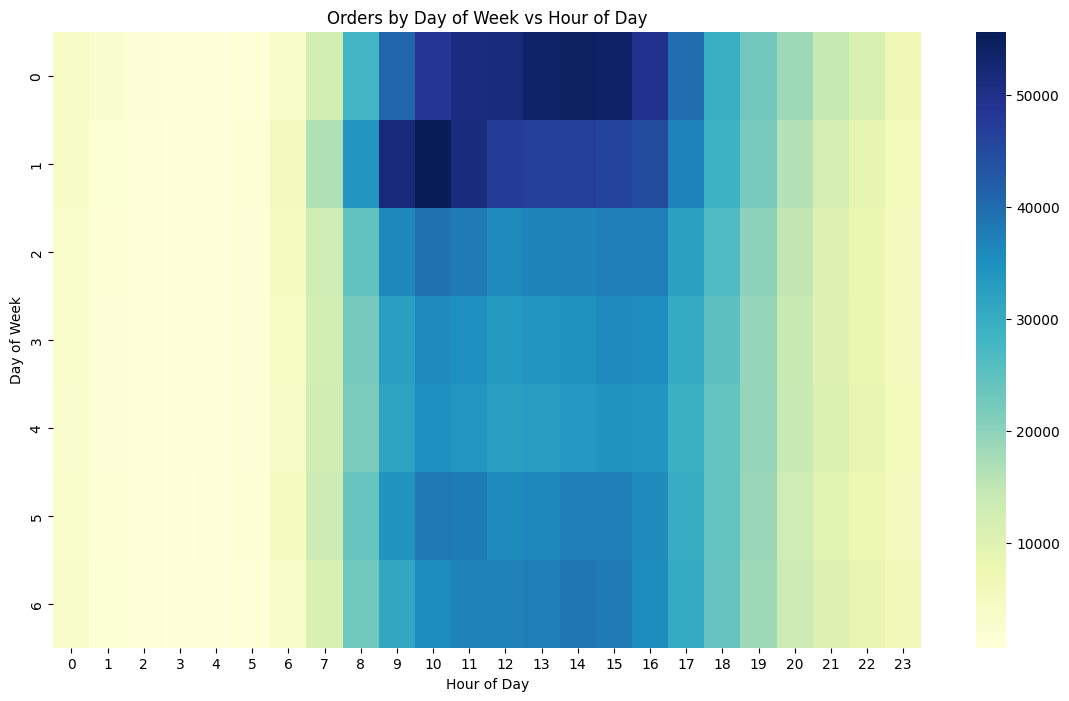

In [ ]:
# Vizualize how often users place orders
plt.figure()
sns.histplot(orders['days_since_prior_order'].dropna(), bins=30, kde=True)
plt.title('Distribution of Days Since Previous Order')
plt.xlabel('Days Since Prior Order')
plt.show()


plt.figure()
sns.countplot(data=orders, x='order_dow', palette='viridis')
plt.title('Orders by Day of Week (0 = Sunday)')
plt.show()

# Heatmap (very useful insight)
dow_hour = orders.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 8))
sns.heatmap(dow_hour, cmap='YlGnBu')
plt.title('Orders by Day of Week vs Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

##Model Architecture

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import random_split, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

#Feature Engineering